**¡Hola Angel!** 😊

Mi nombre es **Alejandro Castellanos** y hoy tengo el placer de ser el revisor de tu proyecto.

Voy a revisar todo tu código con detalle, buscando tanto los puntos fuertes como aquellos en los que podrías mejorar. Te dejaré comentarios a lo largo del notebook, destacando lo que has hecho bien y sugiriendo ajustes donde sea necesario. Si encuentro algún error, no te preocupes, te lo haré saber de forma clara y te daré información útil para que puedas corregirlo en la próxima iteración. Si en algún punto tienes comentarios, siéntete libre de dejarlos también.


Encontrarás mis comentarios específicos dentro de cajas verdes, amarillas o rojas, es muy importante que no muevas, modifiques o borres mis comentarios, con el fin de tener un seguimiento adecuado de tu proceso:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

A continuación te dejaré un comentario general con mi valoración del proyecto. **¡Mi objetivo es que sigas aprendiendo y mejorando con cada paso!**

---

---

# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

El propósito del proyecto consiste en saber cuál de las dos tarifas (Surf o Ultimate) genera más ingresos. En otras palabras, calcular el total de ingresos generados por cada plan. De esta manera sabrá la empresa en cuál de las dos tarifas invertir más publicidad. Primeramente debo limpiar/preparar los datos (eliminar duplicados, valores ausentes, errores de tipos de datos, hacer ciertas transformaciones, etc), después viene el análisis, en el que voy a estudiar el comportamiento de los clientes (llamadas, mensajes, datos gastados, etc) y con todo esto voy a poder determinar el total de ingresos de cada plan de Megaline. Al tener estos datos, podré comparar los datos estadísticos de las dos tarifas entre sí; para así poder determinar si hay diferencias significativas entre sus ingresos, y cuál es el que más dinero genera.

## Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
from scipy import stats as st
from matplotlib import pyplot as plt
from math import factorial

## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrame

df_calls = pd.read_csv('/datasets/megaline_calls.csv')
df_internet = pd.read_csv('/datasets/megaline_internet.csv')
df_messages = pd.read_csv('/datasets/megaline_messages.csv')
df_plans = pd.read_csv('/datasets/megaline_plans.csv')
df_users = pd.read_csv('/datasets/megaline_users.csv')

## Preparar los datos

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
df_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
# Imprime una muestra de los datos para las tarifas

print(df_plans) #aquí imprimí todo el dataframe ya que este es muy pequeño

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

**Para ser sincero, a primera instancia creí que debía cambiar los tipos de datos de usd_monthly_pay y usd_per_gb a float64 para que fuesen igual a usd_per_message y usd_per_minute, pero después me di cuenta que eso no tenía ningún sentido ya que los dos primeros siempre van a ser números enteros. No veo datos ausentes ni datos duplicados. Pero algo que sí podríamos hacer es organizar este dataframe poniendo las tarifas como índice. Otra cosa que me gustaría hacer personalmente es cambiar el nombre de 'mb_per_month_included' a solo 'mb_included' para que sea igual que los otros dos y evitar confusiones. Aunque parace que todo está bien, hay que estandarizar los nombres de las columnas, para asegurarnos de que todas tengan el mismo formato**

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Es una excelente idea que hayas decidido escribir tu plan de acción, ya que esto no solo te ayudará a organizar tus ideas, sino que también te permitirá tener una visión más clara y estructurada del trabajo que realizarás con los datos. Este enfoque te ayudará a mantenerte enfocado y a avanzar de manera más eficiente hacia tus objetivos. ¡Muy buen trabajo, sigue así!

</div>

## Corregir datos

In [5]:
#estandarizar los nombres de las columnas
new_cols_names = []
for name in df_plans.columns:
    new_name = name.strip().lower().replace(' ', '_')
    new_cols_names.append(new_name)
df_plans.columns = new_cols_names

df_plans = df_plans.set_index('plan_name') #indexar por tarifa
df_plans.rename(columns={'mb_per_month_included':'mb_included'}, inplace=True)#cambiar nombre
print(df_plans) #Aquí verifico mi código

           messages_included  mb_included  minutes_included  usd_monthly_pay  \
plan_name                                                                      
surf                      50        15360               500               20   
ultimate                1000        30720              3000               70   

           usd_per_gb  usd_per_message  usd_per_minute  
plan_name                                               
surf               10             0.03            0.03  
ultimate            7             0.01            0.01  


## Enriquecer los datos

**Podríamos crear una nueva columna en donde se muestren los usd por mb excedidos ya que intuyo que ocuparemos
esto más adelante y de esta manera facilitaremos la compración. **(Ya ibaen el paso 1.12 y me di cuenta que aquí debí haber puesto una nueva columna en donde mostrara los gb incluidos en el plan, así que me regresé a hacerlo**

In [6]:
df_plans['usd_per_mb'] = df_plans['usd_per_gb']/1024
df_plans['gb_included'] = df_plans['mb_included']/1024
print(df_plans) #verificamos

           messages_included  mb_included  minutes_included  usd_monthly_pay  \
plan_name                                                                      
surf                      50        15360               500               20   
ultimate                1000        30720              3000               70   

           usd_per_gb  usd_per_message  usd_per_minute  usd_per_mb  \
plan_name                                                            
surf               10             0.03            0.03    0.009766   
ultimate            7             0.01            0.01    0.006836   

           gb_included  
plan_name               
surf              15.0  
ultimate          30.0  


## Usuarios/as

In [7]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [8]:
# Imprime una muestra de datos para usuarios
print(df_users.sample(n=10))

     user_id first_name last_name  age  \
182     1182       Jeff      Burt   39   
71      1071        Isa       Roy   29   
155     1155     Claude      Hahn   19   
105     1105    Micheal     Poole   57   
233     1233      Janee   Perkins   33   
354     1354     Leonel      Dyer   41   
219     1219      Gavin    Keller   51   
383     1383  Margarito     Mccoy   52   
230     1230      Andre     Estes   38   
213     1213       Carl    Newman   47   

                                              city    reg_date      plan  \
182          Charlotte-Concord-Gastonia, NC-SC MSA  2018-05-29      surf   
71       New York-Newark-Jersey City, NY-NJ-PA MSA  2018-05-23      surf   
155  Miami-Fort Lauderdale-West Palm Beach, FL MSA  2018-02-21  ultimate   
105                  Providence-Warwick, RI-MA MSA  2018-01-08      surf   
233          Atlanta-Sandy Springs-Roswell, GA MSA  2018-09-11      surf   
354      New York-Newark-Jersey City, NY-NJ-PA MSA  2018-08-24  ultimate   
219  

**Puedo observar que el tipo de datos de las fechas de registro y de salida no son de tipo datetime, entonces hay que cambiarlas. En cuanto a datos duplicados, los comprobaré a continuación, y en cuanto a valores ausentes, puedo observar que solo la columna churn_date consta de estos, pero hace sentido ya que como dijeron al principio, significa que estaban usando el servicio cuando fue extraída esta base de datos. Por último podemos ver que la columna city consta de mayúsculas y minúsculas así que hay que cambiar esto para que todas sean minúsculas. Hay que estandarizar los nombres de las columnas**

### Corregir los datos

In [9]:
#estandarizar los nombres de las columnas
new_cols_names = []
for name in df_users.columns:
    new_name = name.strip().lower().replace(' ', '_')
    new_cols_names.append(new_name)
df_users.columns = new_cols_names

#convertir columnas a tipo datetime
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'])
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'])

#estandarizar la columna city
df_users['city'] = df_users['city'].str.lower()

#verificar valores duplicados
print('valores duplicados:', df_users.duplicated().sum())

#Comprobar exito del código
print()
df_users.info()
print()
print(df_users.sample(n=10))

valores duplicados: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB

     user_id first_name   last_name  age  \
148     1148      Dwana       Moore   67   
278     1278     Masako  Montgomery   39   
295     1295       Hung     Flowers   68   
345     1345   Pasquale    Caldwell   26   
385     1385     Nohemi    Erickson   52   
36      1036      Myron       Hodge   70   
222     1222  

### Enriquecer los datos

**Al principio quería reemplazar los valores ausentes por una cadena de texto que indicara que el usuario aún estaba usando el servicio, pero después me di cuenta que era mejor agregar una columna que, dependiendo si el valor de churn_date es un valor nulo o no, me mostrará si el usuario seguía activo. Al hacer el paso 1.8.2, me di cuenta que aquí también puedo mostrar el mes de cuando los usuarios dejaron de usar el servicio**

In [10]:
df_users['active'] = df_users['churn_date'].isna() #mostrar si el usuario sigue activo
df_users['churn_month'] = df_users['churn_date'].dt.month #mostar el mes que dejaron de usar el servicio en número
df_users['churn_month_name'] = df_users['churn_date'].dt.month_name() #mostar el mes que dejaron de usar el servicio en texto
df_users.info()
print()
print(df_users.sample(n=10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           500 non-null    int64         
 1   first_name        500 non-null    object        
 2   last_name         500 non-null    object        
 3   age               500 non-null    int64         
 4   city              500 non-null    object        
 5   reg_date          500 non-null    datetime64[ns]
 6   plan              500 non-null    object        
 7   churn_date        34 non-null     datetime64[ns]
 8   active            500 non-null    bool          
 9   churn_month       34 non-null     float64       
 10  churn_month_name  34 non-null     object        
dtypes: bool(1), datetime64[ns](2), float64(1), int64(2), object(5)
memory usage: 39.7+ KB

     user_id first_name last_name  age  \
185     1185      Loria   Freeman   47   
251     1251     

## Llamadas

In [11]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [12]:
# Imprime una muestra de datos para las llamadas
print(df_calls.sample(n=10))

             id  user_id   call_date  duration
31461  1118_243     1118  2018-12-12      0.00
41373  1152_425     1152  2018-12-21      5.93
68745   1247_78     1247  2018-11-07      0.00
45314   1164_13     1164  2018-11-15      9.22
7121   1033_137     1033  2018-11-27      0.91
30386  1114_145     1114  2018-10-25      2.51
92608  1333_226     1333  2018-12-21      9.72
51691  1185_729     1185  2018-06-09      3.81
85828   1316_62     1316  2018-08-10     12.49
44781  1161_468     1161  2018-12-14      3.10


**Veo que debo cambiar los tipos de datos de call_date a tipo datetime; por otro lado, hay que cambiar la columna id a entero, pero para esto, hay que deshacernos de ese guión que está en medio y quedarnos únicamente con la parte derecha, y por último, yo en lo personal cambiaría el nombre de esta columna por 'call_id' para más claridad. Que la duración esté en float me parece correcto ya que para representar esas fracciones de minuto (los segundos) necesitamos esos decimales, pero debido a que Megaline redondea los segundos a minutos, hay que hacer esta acción. En cuanto a valores duplicados, los revisaré a continuación, y en cuanto a valores ausentes, no veo ninguno presente. Debemos estandarizar los nombres de las columnas.**

### Corregir los datos

In [13]:
#estandarizar los nombres de las columnas
new_cols_names = []
for name in df_calls.columns:
    new_name = name.strip().lower().replace(' ', '_')
    new_cols_names.append(new_name)
df_calls.columns = new_cols_names

#cambiar tipo de datos de la columna call_date
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'])
#corregir y cambiar tipo de datos de la columna id
df_calls['id'] = df_calls['id'].str.split('_').str[1].astype(int)
#renombrar columna id
df_calls.rename(columns={'id':'call_id'}, inplace=True)
#redondear columna duration a minutos
df_calls['duration'] = df_calls['duration'].apply(np.ceil).astype(int)
#revisar duplicados
print('Valores duplicados:', df_calls.duplicated().sum())

#Revisar éxito del código
print()
df_calls.info()
print()
print(df_calls.sample(n=10))

Valores duplicados: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   call_id    137735 non-null  int64         
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 4.2 MB

        call_id  user_id  call_date  duration
106760      312     1377 2018-12-18         3
92089       370     1330 2018-12-30         8
125530       60     1444 2018-11-13        19
126885      285     1451 2018-09-08         0
102650      178     1364 2018-09-16         0
136778      230     1495 2018-09-14         6
74865       136     1264 2018-12-05         9
62555        19     1225 2018-12-31         5
34889       198     1132 2018-05-10         0
30123       415     1113 2018-12-06        13


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

¡Muy buen trabajo, nombre! Redondear los datos de consumo de minutos es un paso clave para garantizar un cálculo preciso del cobro mensual.

</div>

### Enriquecer los datos

**Podemos extraer el mes de la columna call_date para después analizar el número de llamadas hechas por mes.**

In [14]:
df_calls['call_month'] = df_calls['call_date'].dt.month #muestro el mes en número (para mayor facilidad en los análisis)
df_calls['call_month_name'] = df_calls['call_date'].dt.month_name() #muestro el mes en texto (para mayor flexibilidad)
df_calls.info()
print()
print(df_calls.sample(n=10)) #Verificamos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   call_id          137735 non-null  int64         
 1   user_id          137735 non-null  int64         
 2   call_date        137735 non-null  datetime64[ns]
 3   duration         137735 non-null  int64         
 4   call_month       137735 non-null  int64         
 5   call_month_name  137735 non-null  object        
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 6.3+ MB

        call_id  user_id  call_date  duration  call_month call_month_name
78024       152     1279 2018-11-25        16          11        November
113970      312     1400 2018-12-21         0          12        December
9328        257     1042 2018-02-11         0           2        February
56119       218     1201 2018-06-27        11           6            June
104282      139   

## Mensajes

In [15]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [16]:
# Imprime una muestra de datos para los mensajes
print(df_messages.sample(n=10))

              id  user_id message_date
13666   1090_175     1090   2018-06-11
37319   1247_483     1247   2018-11-03
55597   1349_359     1349   2018-10-23
47708   1324_425     1324   2018-11-20
45103    1303_22     1303   2018-12-16
2404    1028_316     1028   2018-07-04
21052   1132_231     1132   2018-12-06
25651    1155_10     1155   2018-09-28
25377   1151_220     1151   2018-12-03
48429  1324_1163     1324   2018-09-14


**El id de SMS tiene el mismo error que vimos anteriormente. Hay que separar por el guion y quedarnos unicamente con lo queda en el índice derecho (o sea, [1]). Después se convierte a tipo int y por último cambiar su nombre a sms_id para mayor claridad. Por otro lado, hay que convertir también la columna message_date a tipo datetime. Hay que revisar si hay datos duplicados a continuación y tal parace que en esta tabla no existen valores ausentes. Como siempre, debemos estandarizar los nombres de las columnas**

### Corregir los datos

In [17]:
#estandarizar los nombres de las columnas
new_cols_names = []
for name in df_messages.columns:
    new_name = name.strip().lower().replace(' ', '_')
    new_cols_names.append(new_name)
df_messages.columns = new_cols_names

df_messages['id'] = df_messages['id'].str.split('_').str[1].astype(int) #corregir y convertir tipos de datos de la columna id
df_messages.rename(columns={'id':'sms_id'}, inplace=True) #cambiar nombre de la columna id
df_messages['message_date'] = pd.to_datetime(df_messages['message_date']) #convertir columna message_date a datetime
print('Valores duplicados', df_messages.duplicated().sum())    #revisar valores duplicados
#revisar éxito del código
print()
df_messages.info()
print()
print(df_messages.sample(n=10))

Valores duplicados 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   sms_id        76051 non-null  int64         
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2)
memory usage: 1.7 MB

       sms_id  user_id message_date
22124    1741     1132   2018-04-16
70279     239     1456   2018-06-10
5256       13     1052   2018-12-21
53234     368     1339   2018-12-01
4653        5     1044   2018-10-22
9         525     1000   2018-12-28
68606      89     1444   2018-12-12
70689     183     1460   2018-12-28
40543     190     1261   2018-12-12
58866      40     1374   2018-07-08


### Enriquecer los datos

**Podemos mostrar el mes, al igual que como hemos hecho anteriormente.**

In [18]:
df_messages['message_month'] = df_messages['message_date'].dt.month #mostramos el mes con número
df_messages['message_month_name'] = df_messages['message_date'].dt.month_name() #mostramos el mes con texto

df_messages.info()
print()
print(df_messages.sample(n=10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   sms_id              76051 non-null  int64         
 1   user_id             76051 non-null  int64         
 2   message_date        76051 non-null  datetime64[ns]
 3   message_month       76051 non-null  int64         
 4   message_month_name  76051 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 2.9+ MB

       sms_id  user_id message_date  message_month message_month_name
3019       32     1033   2018-10-24             10            October
70385      12     1458   2018-12-30             12           December
33190       1     1207   2018-12-26             12           December
25014     217     1147   2018-07-29              7               July
6066      184     1055   2018-05-18              5                May
35510     

## Internet

In [19]:
# Imprime la información general/resumida sobre el DataFrame de internet
df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [20]:
# Imprime una muestra de datos para el tráfico de internet
print(df_internet.sample(n=10))

              id  user_id session_date  mb_used
102280   1490_95     1490   2018-07-29   807.35
34827   1156_424     1156   2018-12-19   225.26
74440    1350_14     1350   2018-11-26   104.68
1863     1010_16     1010   2018-06-14    40.54
33532   1152_160     1152   2018-11-22   539.04
1998    1010_165     1010   2018-09-14   903.83
51781   1232_364     1232   2018-08-08     0.00
63389    1292_93     1292   2018-10-17   521.29
103270  1494_152     1494   2018-08-17   247.71
46081    1204_14     1204   2018-12-03   467.47


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

**Hay que corregir la columna id ya que tiene el mismo problema de antes, y cambiar su tipo a int. También cambiar su nombre para mayor claridad. Cambiar la columna session_date a datetime, revisar duplicados y valores ausentes.**

### Corregir los datos

In [21]:
#estandarizar los nombres de las columnas
new_cols_names = []
for name in df_internet.columns:
    new_name = name.strip().lower().replace(' ', '_')
    new_cols_names.append(new_name)
df_internet.columns = new_cols_names

#corregir columna id y cambiar su tipo a int
df_internet['id'] = df_internet['id'].str.split('_').str[1].astype(int)
#cambiar nombre de la columna id
df_internet.rename(columns={'id':'session_id'}, inplace=True)
#cambiar columna session_date a datetime
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'])
#revisar duplicados
print('Valores duplicados', df_internet.duplicated().sum())
#revisar éxito del código
print()
df_internet.info()
print()
print(df_internet.sample(n=10))

Valores duplicados 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   session_id    104825 non-null  int64         
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 3.2 MB

        session_id  user_id session_date  mb_used
34264          312     1155   2018-06-28   400.84
25657          175     1120   2018-06-19   604.83
24925          322     1114   2018-11-01   715.46
74004           99     1347   2018-11-18   220.69
102255          70     1490   2018-08-12   706.38
1701           236     1009   2018-07-18   283.58
81128           50     1380   2018-11-19   405.01
17695           26     1080   2018-09-04   347.69
24272           38     1111   2018-12-05  

### Enriquecer los datos

**Nuevamente, podemos mostrar el mes en que se realizó la sesión, para después poder hacer análisis con esto. También podemos mostrar en una nueva columna los gb usados en la sesión.**

In [22]:
df_internet['session_month'] = df_internet['session_date'].dt.month    #mostrar el mes con número
df_internet['session_month_name'] = df_internet['session_date'].dt.month_name()    #mostrar el mes con texto
df_internet['gb_used'] = df_internet['mb_used']/1024  #mostrar gb usados en la sesión

df_internet.info()
print()
print(df_internet.sample(n=10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   session_id          104825 non-null  int64         
 1   user_id             104825 non-null  int64         
 2   session_date        104825 non-null  datetime64[ns]
 3   mb_used             104825 non-null  float64       
 4   session_month       104825 non-null  int64         
 5   session_month_name  104825 non-null  object        
 6   gb_used             104825 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 5.6+ MB

       session_id  user_id session_date  mb_used  session_month  \
53724          26     1243   2018-12-18   536.98             12   
22763          32     1104   2018-12-25   215.92             12   
16046         498     1072   2018-10-25   139.57             10   
54052          85     1245 

**ESTANDARIZAR VALORES DENTRO DE CADA COLUMNA DE TODOS LOS DATAFRAMES ELIMINANDO ESPACIOS AL PRINCIPIO Y AL FINAL DE CADA VALOR. Me di cuenta que no había considerado este paso así que me regresé a hacerlo**

In [23]:
#aquí guardamos los dataframes con sus nombres con pares clave valor en un diccionario
dataframes = {'df_users':df_users, 'df_calls':df_calls, 'df_messages':df_messages, 'df_internet':df_internet}

for name, df in dataframes.items(): #recorremos ese diccionario
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].str.strip() #estandarizamos los valores dentro de todas las columnas de tipo object de todos los dataframes

**REVISAR VALORES AUSENTES EXPLÍCITOS**

In [24]:
# Revisar valores ausentes explícitos en df_users, df_calls, df_messages y df_internet:

print('Valores ausentes tipo NaN en df_users:\n', df_users.isna().sum(), '\n')
print('Valores ausentes tipo NaN en df_calls:\n', df_calls.isna().sum(), '\n')
print('Valores ausentes tipo NaN en df_messages:\n', df_messages.isna().sum(), '\n')
print('Valores ausentes tipo NaN en df_internet:\n', df_internet.isna().sum(), '\n')


Valores ausentes tipo NaN en df_users:
 user_id               0
first_name            0
last_name             0
age                   0
city                  0
reg_date              0
plan                  0
churn_date          466
active                0
churn_month         466
churn_month_name    466
dtype: int64 

Valores ausentes tipo NaN en df_calls:
 call_id            0
user_id            0
call_date          0
duration           0
call_month         0
call_month_name    0
dtype: int64 

Valores ausentes tipo NaN en df_messages:
 sms_id                0
user_id               0
message_date          0
message_month         0
message_month_name    0
dtype: int64 

Valores ausentes tipo NaN en df_internet:
 session_id            0
user_id               0
session_date          0
mb_used               0
session_month         0
session_month_name    0
gb_used               0
dtype: int64 



**REVISAR VALORES AUSENTES IMPLÍCITOS:
Aquí quise revisar los valores ausentes de forma más precisa, ya que me di cuenta que no lo había considerado. (la verdad no me queda claro si esta sea la opción más factible para hacerlo)**

In [25]:
# Revisar valores únicos en df_users
print('Valores únicos en df_users:')
for col in df_users.columns:
    print(f'Valores únicos en {col}:\n', df_users[col].value_counts(dropna=False, ascending=True), '\n')

# Revisar valores únicos en df_calls
print('Valores únicos en df_calls:')
for col in df_calls.columns:
    print(f'Valores únicos en {col}:\n', df_calls[col].value_counts(dropna=False, ascending=True), '\n')

# Revisar valores únicos en df_messages
print('Valores únicos en df_messages:')
for col in df_messages.columns:
    print(f'Valores únicos en {col}:\n', df_messages[col].value_counts(dropna=False, ascending=True), '\n')

# Revisar valores únicos en df_internet
print('Valores únicos en df_internet:')
for col in df_internet.columns:
    print(f'Valores únicos en {col}:\n', df_internet[col].value_counts(dropna=False, ascending=True), '\n')

# Agregué el ascending=True para que los valores que menos se repiten, los cuales considero que son los más raros, aparezcan hasta arriba

Valores únicos en df_users:
Valores únicos en user_id:
 1024    1
1365    1
1364    1
1363    1
1362    1
       ..
1183    1
1182    1
1181    1
1194    1
1023    1
Name: user_id, Length: 500, dtype: int64 

Valores únicos en first_name:
 Elton       1
Milford     1
Randolph    1
Kymberly    1
Edmundo     1
           ..
Robt        2
Andre       2
Seymour     3
Leonila     3
Jasper      3
Name: first_name, Length: 458, dtype: int64 

Valores únicos en last_name:
 Hobbs        1
Pena         1
Mccall       1
Cotton       1
Giles        1
            ..
David        3
Velazquez    3
Conley       3
Hoffman      3
Morrison     3
Name: last_name, Length: 399, dtype: int64 

Valores únicos en age:
 68     2
43     3
72     4
62     4
32     4
73     5
58     5
35     6
74     6
40     6
37     6
54     6
31     6
63     6
55     6
71     6
24     6
50     6
48     7
25     7
38     7
41     7
22     7
57     7
59     8
21     8
44     8
19     8
56     9
66     9
60     9
23     9
46    10

**Pude notar que tanto la columna duration en la tabla df_calls como la columna mb_used en la tabla df_internet, tienen valores representados por ceros. Lo que quiere decir que no hay información de la duración de ciertas llamadas ni del consumo de datos de ciertas sesiones. Decidí no eliminar estas filas de sus respectivos dataframes ya que pienso que, aunque no tenga dicha información de esos datos, podría seguir siendo importante saber el número total de llamadas o sesiones realizadas en un futuro.**

****Ya iba más adelante pero al final regresé a este paso ya que después de pensarlo mucho creo que sí es mejor eliminar las filas donde no hay información sobre la duración de llamadas y el consumo de datos de sesiones. Ya que no creo que me sea útil saber únicamente el número total de estos dos.**** 

In [26]:
#Eliminar filas con el número cero en df_calls['duration'] y en df_internet['mb_used']
df_calls = df_calls[df_calls['duration'] > 0]
df_internet = df_internet[df_internet['mb_used'] > 0]
#comprobamos:
print(df_calls[df_calls['duration'] == 0])
print(df_internet[df_internet['mb_used'] == 0])

Empty DataFrame
Columns: [call_id, user_id, call_date, duration, call_month, call_month_name]
Index: []
Empty DataFrame
Columns: [session_id, user_id, session_date, mb_used, session_month, session_month_name, gb_used]
Index: []


**REVISAR FILAS COMPLETAMENTE DUPLICADAS**:

In [27]:
#Revisar filas completamente duplicadas en cada uno de los dataframes a excepción de df_plans
for name, df in dataframes.items(): #recorremos el diccionario anterior
    print(f'Filas duplicadas en {name}:\n', df.duplicated().sum(), '\n')

Filas duplicadas en df_users:
 0 

Filas duplicadas en df_calls:
 0 

Filas duplicadas en df_messages:
 0 

Filas duplicadas en df_internet:
 0 



<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

¡Excelente trabajo en el análisis exploratorio de datos! Usaste correctamente las funciones `info` y `head` para revisar la estructura y el contenido de los datos, lo que te permitió realizar los ajustes necesarios. Además hiciste un análisis minucioso de los valores de cada dataset además de la presencia de datos duplicados y faltantes. Esto facilitará el análisis de los datos y el desarrollo de las demás etapas del proyecto.


</div>

## Estudiar las condiciones de las tarifas

In [28]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
print(df_plans)

           messages_included  mb_included  minutes_included  usd_monthly_pay  \
plan_name                                                                      
surf                      50        15360               500               20   
ultimate                1000        30720              3000               70   

           usd_per_gb  usd_per_message  usd_per_minute  usd_per_mb  \
plan_name                                                            
surf               10             0.03            0.03    0.009766   
ultimate            7             0.01            0.01    0.006836   

           gb_included  
plan_name               
surf              15.0  
ultimate          30.0  


In [29]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
df_monthly_calls = df_calls.groupby(['user_id', 'call_month'])['call_id'].count().reset_index()
print(df_monthly_calls.head(20))

    user_id  call_month  call_id
0      1000          12       16
1      1001           8       22
2      1001           9       38
3      1001          10       47
4      1001          11       49
5      1001          12       46
6      1002          10        8
7      1002          11       48
8      1002          12       38
9      1003          12      118
10     1004           5       19
11     1004           6       33
12     1004           7       45
13     1004           8       42
14     1004           9       32
15     1004          10       47
16     1004          11       45
17     1004          12       43
18     1005          12       50
19     1006          11        2


In [30]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.

df_monthly_minutes = df_calls.groupby(['user_id', 'call_month'])['duration'].sum().reset_index()
print(df_monthly_minutes)

      user_id  call_month  duration
0        1000          12       124
1        1001           8       182
2        1001           9       315
3        1001          10       393
4        1001          11       426
...       ...         ...       ...
2251     1498          12       339
2252     1499           9       346
2253     1499          10       385
2254     1499          11       308
2255     1499          12       496

[2256 rows x 3 columns]


In [31]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
df_monthly_messages = df_messages.groupby(['user_id', 'message_month'])['sms_id'].count().reset_index()
print(df_monthly_messages)

      user_id  message_month  sms_id
0        1000             12      11
1        1001              8      30
2        1001              9      44
3        1001             10      53
4        1001             11      36
...       ...            ...     ...
1801     1496              9      21
1802     1496             10      18
1803     1496             11      13
1804     1496             12      11
1805     1497             12      50

[1806 rows x 3 columns]


In [32]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
#aquí redondeo los el total de gb usados al mes ya que esto es lo que se va a considerar para cobrar
df_monthly_gb = df_internet.groupby(['user_id', 'session_month'])['gb_used'].sum().apply(np.ceil).astype(int).reset_index()
print(df_monthly_gb)

      user_id  session_month  gb_used
0        1000             12        2
1        1001              8        7
2        1001              9       14
3        1001             10       22
4        1001             11       19
...       ...            ...      ...
2272     1498             12       23
2273     1499              9       13
2274     1499             10       20
2275     1499             11       17
2276     1499             12       22

[2277 rows x 3 columns]


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>


Muy buen trabajo al utilizar la función `ceil` para redondear el consumo de internet. Este paso es fundamental para garantizar un cálculo preciso del cobro mensual.



</div>

In [33]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month

#aquí me di cuenta de que tenía que volver a renombrar las columnas de los meses para que todas fuesen iguales y puediera hacer la fusión
df_monthly_calls = df_monthly_calls.rename(columns={'call_month': 'month'})
df_monthly_minutes = df_monthly_minutes.rename(columns={'call_month': 'month'})
df_monthly_messages = df_monthly_messages.rename(columns={'message_month': 'month'})
df_monthly_gb = df_monthly_gb.rename(columns={'session_month': 'month'})

#realizamos la fusión de los cautro dataframes por su usuario y mes
df_merged = df_monthly_calls.merge(df_monthly_minutes, on=['user_id', 'month'])
df_merged = df_merged.merge(df_monthly_messages, on=['user_id', 'month'])
users_consumption = df_merged.merge(df_monthly_gb, on=['user_id', 'month'])
print(users_consumption.head(10))
print()
users_consumption.info()

   user_id  month  call_id  duration  sms_id  gb_used
0     1000     12       16       124      11        2
1     1001      8       22       182      30        7
2     1001      9       38       315      44       14
3     1001     10       47       393      53       22
4     1001     11       49       426      36       19
5     1001     12       46       412      44       19
6     1002     10        8        59      15        7
7     1002     11       48       386      32       19
8     1002     12       38       384      41       15
9     1003     12      118      1104      50       27

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1758 entries, 0 to 1757
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   user_id   1758 non-null   int64
 1   month     1758 non-null   int64
 2   call_id   1758 non-null   int64
 3   duration  1758 non-null   int64
 4   sms_id    1758 non-null   int64
 5   gb_used   1758 non-null   int64
dty

In [34]:
# Añade la información de la tarifa
df_plans_reset = df_plans.reset_index() #Aquí me di cuenta que era mejor tener tabla de los planes como estaba en un principio, entonces la reseteé.
#1. Tengo que fusionar la tabla de users con la tabla de plans:
    # para eso, primero renombro el nombre de la la columna de la tarifa de una de las tablas para que sen iguales entre sí
df_users = df_users.rename(columns={'plan':'plan_name'})
    #ahora ya puedo hacer el merge entre esas dos
users_and_plans = df_users.merge(df_plans_reset, on='plan_name')
#2. Tengo que fusionar el dataframe resultante con el dataframe users_consumption
consumption_and_plans = users_consumption.merge(users_and_plans, on='user_id')
print(consumption_and_plans.head(10))
print()
consumption_and_plans.info()

   user_id  month  call_id  duration  sms_id  gb_used first_name  last_name  \
0     1000     12       16       124      11        2   Anamaria      Bauer   
1     1001      8       22       182      30        7     Mickey  Wilkerson   
2     1001      9       38       315      44       14     Mickey  Wilkerson   
3     1001     10       47       393      53       22     Mickey  Wilkerson   
4     1001     11       49       426      36       19     Mickey  Wilkerson   
5     1001     12       46       412      44       19     Mickey  Wilkerson   
6     1002     10        8        59      15        7     Carlee    Hoffman   
7     1002     11       48       386      32       19     Carlee    Hoffman   
8     1002     12       38       384      41       15     Carlee    Hoffman   
9     1003     12      118      1104      50       27   Reynaldo    Jenkins   

   age                                   city  ... churn_month_name  \
0   45  atlanta-sandy springs-roswell, ga msa  ...         

In [35]:
# Calcula el ingreso mensual para cada usuario

#POR USUARIO

#1. Minutos excedidos = (número total de minutos gastados) - (límite del paquete gratuito)
#Costo por exceso de minutos = (Minutos excedidos) * (costo por minuto excedido)

#2. Mensajes excedidos = (número total de mensajes enviados) - (límite del paquete gratuito)
#Costo por exceso de mensajes = (Mensajes excedidos) * (costo por mensaje excedido)

#3. GB excedidos = (número total de GB usados) - (límite del paquete gratuito)
#Costo por exceso de GB = (GB excedidos) * (costo por GB excedido)

#4.Cuota Mensual

#5.Ingreso total mensual = (Costo por exceso de minutos) + (Costo por exceso de mensajes) + (Costo por exceso de GB) + (Cuota Mensual)

#Minutos
consumption_and_plans['exceeded_minutes'] = np.where(consumption_and_plans['duration'] > consumption_and_plans['minutes_included'],
                                                    consumption_and_plans['duration'] - consumption_and_plans['minutes_included'],
                                                    0)
consumption_and_plans['extra_charge_per_minutes'] = (consumption_and_plans['exceeded_minutes']) * (consumption_and_plans['usd_per_minute'])
#Mensajes
consumption_and_plans['exceeded_messages'] = np.where(consumption_and_plans['sms_id'] > consumption_and_plans['messages_included'],
                                                    consumption_and_plans['sms_id'] - consumption_and_plans['messages_included'],
                                                    0)
consumption_and_plans['extra_charge_per_messages'] = (consumption_and_plans['exceeded_messages']) * (consumption_and_plans['usd_per_message'])
#GB
consumption_and_plans['exceeded_gb'] = np.where(consumption_and_plans['gb_used'] > consumption_and_plans['gb_included'],
                                                    consumption_and_plans['gb_used'] - consumption_and_plans['gb_included'],
                                                    0)
consumption_and_plans['extra_charge_per_gb'] = (consumption_and_plans['exceeded_gb']) * (consumption_and_plans['usd_per_gb'])

#monthly_fee = usd_monthly_pay

consumption_and_plans['monthly_income'] = consumption_and_plans['usd_monthly_pay'] + consumption_and_plans['extra_charge_per_minutes'] + consumption_and_plans['extra_charge_per_messages'] + consumption_and_plans['extra_charge_per_gb']

consumption_and_plans.info()
print()
print(consumption_and_plans.head(10))

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1758 entries, 0 to 1757
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   user_id                    1758 non-null   int64         
 1   month                      1758 non-null   int64         
 2   call_id                    1758 non-null   int64         
 3   duration                   1758 non-null   int64         
 4   sms_id                     1758 non-null   int64         
 5   gb_used                    1758 non-null   int64         
 6   first_name                 1758 non-null   object        
 7   last_name                  1758 non-null   object        
 8   age                        1758 non-null   int64         
 9   city                       1758 non-null   object        
 10  reg_date                   1758 non-null   datetime64[ns]
 11  plan_name                  1758 non-null   object        
 12  churn_

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

¡Perfecto, name! Hiciste un excelente uso de las funciones `groupby`  y `merge`, logrando agrupar correctamente la información de consumo de llamadas, mensajes e internet de cada usuario por mes. Además, calculaste de manera precisa el cobro mensual y reflejaste los valores correctos en la columna *monthly_income*. ¡Buen trabajo!


</div>

## Estudia el comportamiento de usuario

### Llamadas

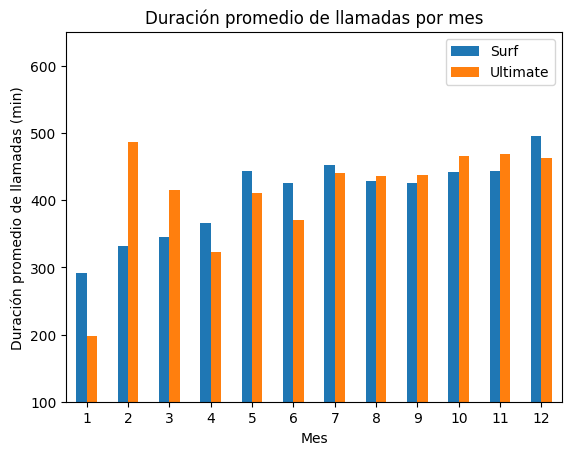

In [36]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

#1.Filtrar por plan
#2.Agrupar por mes
surf_plan = consumption_and_plans[consumption_and_plans['plan_name']=='surf']
surf_plan = surf_plan.rename(columns={'duration':'surf_duration'})#cambiar nombre de columna
surf_plan = surf_plan.groupby('month')['surf_duration'].mean().reset_index()
#-------------------------------
ultimate_plan = consumption_and_plans[consumption_and_plans['plan_name']=='ultimate']
ultimate_plan = ultimate_plan.rename(columns={'duration':'ultimate_duration'})#cambiar nombre de columna
ultimate_plan = ultimate_plan.groupby('month')['ultimate_duration'].mean().reset_index()
#-------------------------------
#3.Hacer un merge
plans_avg_call_duration = surf_plan.merge(ultimate_plan, on='month')
#print('plans_avg_call_duration:\n', plans_avg_call_duration)
#---------------------------
#4.Graficar el dataframe resultante
plans_avg_call_duration.plot(x='month', kind='bar', rot=0)
plt.title('Duración promedio de llamadas por mes')
plt.xlabel('Mes')
plt.ylabel('Duración promedio de llamadas (min)')
plt.legend(['Surf', 'Ultimate'])
plt.ylim([100, 650])

plt.show()

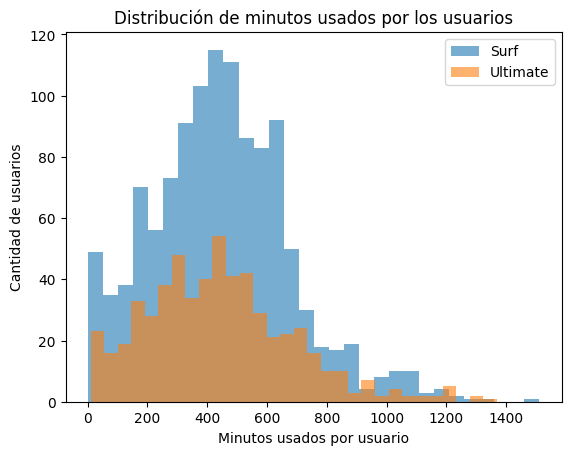

In [37]:
#Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

#Comparar minutos usados por mes, de cada plan
# Llamamos dos veces a plt.hist() para crear dos histogramas en el mismo gráfico
plt.hist(consumption_and_plans[consumption_and_plans['plan_name']=='surf']['duration'], bins=30, alpha=0.6, label='Surf')
plt.hist(consumption_and_plans[consumption_and_plans['plan_name']=='ultimate']['duration'], bins=30, alpha=0.6, label='Ultimate')
plt.title('Distribución de minutos usados por los usuarios')
plt.xlabel('Minutos usados por usuario')
plt.ylabel('Cantidad de usuarios')
plt.legend()
plt.show()



In [38]:
# Calcula la media y la varianza de la duración mensual de llamadas.
#Filtramos por plan y calculamos la media y la varianza respectivamente
surf_mean_duration = consumption_and_plans[consumption_and_plans['plan_name']=='surf']['duration'].mean()
surf_var_duration = np.var(consumption_and_plans[consumption_and_plans['plan_name']=='surf']['duration'], ddof=1)
print('Media de la duración mensual de llamadas del plan Surf:', surf_mean_duration)
print('Varianza de la duración mensual de llamadas del plan Surf:', surf_var_duration)
print()
ultimate_mean_duration = consumption_and_plans[consumption_and_plans['plan_name']=='ultimate']['duration'].mean()
ultimate_var_duration = np.var(consumption_and_plans[consumption_and_plans['plan_name']=='ultimate']['duration'], ddof=1)
print('Media de la duración mensual de llamadas del plan Ultimate:', ultimate_mean_duration)
print('Varianza de la duración mensual de llamadas del plan Ultimate:', ultimate_var_duration)

Media de la duración mensual de llamadas del plan Surf: 445.77542372881356
Varianza de la duración mensual de llamadas del plan Surf: 55321.41262704676

Media de la duración mensual de llamadas del plan Ultimate: 443.2785467128028
Varianza de la duración mensual de llamadas del plan Ultimate: 62056.39194797096


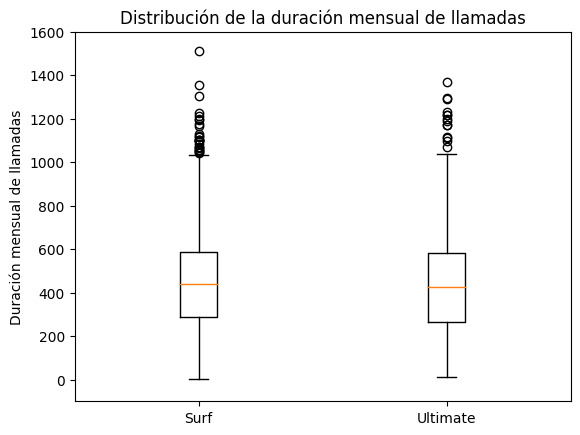

In [39]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

plt.boxplot([consumption_and_plans[consumption_and_plans['plan_name']=='surf']['duration'],
            consumption_and_plans[consumption_and_plans['plan_name']=='ultimate']['duration']], labels=['Surf', 'Ultimate'])
plt.title('Distribución de la duración mensual de llamadas')
plt.ylabel('Duración mensual de llamadas')
plt.ylim([-100, 1600])
plt.show()

**ANTES DE CONTINUAR, CABE DESTACAR QUE LA CANTIDAD DE USUARIOS QUE UTILIZAN EL PLAN SURF ES MAYOR A LA DEL PLAN ULTIMATE, LO QUE PODRÍA INFLUIR SIGNIFICATIVAMENTE SOBRE LA DIFERENCIA DE COMPORTAMIENTOS.**

**¿El comportamiento de los usuarios con respecto a las llamadas varía según el plan? Sí. En primer lugar, podemos observar que la duración promedio de llamadas del plan surf va aumentando cada mes de una forma un poco más gradual que la del plan ultimate. En segundo lugar, existe una diferencia notoria de duración promedio de llamadas entre planes en los primeros tres meses. Por otro lado, a medida que los meses pasan, la duración promedio de las llamadas de los dos planes se van igualando entre sí. Aunado a esto, podemos observar que el plan ultimate constó de un aumento distinguido en la duración promedio de sus llamadas de enero a febrero. Ahora, sobre la distribución de los minutos; en ambos planes, la mayoría de los usuarios utilizan menos de 600 minutos. También podemos observar que aunque son menos los usuarios que utilizan el plan ultimate, la cantidad de usuarios que usaron más de 1200 minutos es mayor en este plan. Y para completar, el promedio de minutos usados por los usuarios del plan Surf es de 445.77, mientras que el del plan Ultimate es de 443.27**

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Has identificado de manera efectiva las diferencias en la duración promedio de las llamadas, destacando cómo el plan Surf muestra un aumento más gradual en comparación con el plan Ultimate, que experimenta un incremento notable entre enero y febrero. Además, señalas acertadamente que, aunque ambos planes tienen una mayoría de usuarios que utilizan menos de 600 minutos, el plan Ultimate tiene una mayor proporción de usuarios que superan los 1200 minutos, lo que sugiere un perfil de uso más intensivo

</div>

### Mensajes

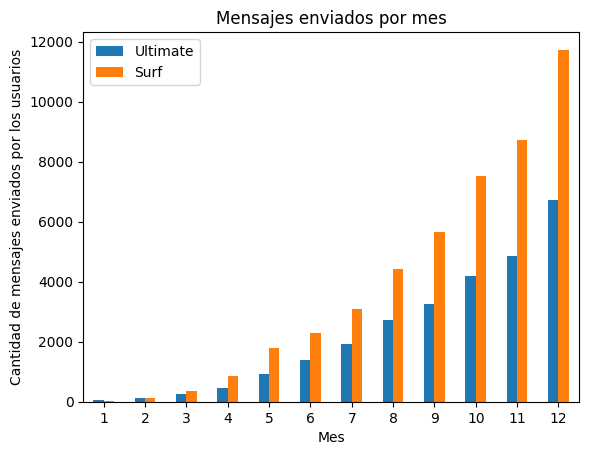

In [40]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
#Compara la columna 'sms_id' por cada plan

monthly_messages_surf = consumption_and_plans[consumption_and_plans['plan_name']=='surf'].groupby('month')['sms_id'].sum()
monthly_messages_ultimate = consumption_and_plans[consumption_and_plans['plan_name']=='ultimate'].groupby('month')['sms_id'].sum()

monthly_sms_both_plans = pd.DataFrame({'Ultimate':monthly_messages_ultimate, 'Surf':monthly_messages_surf})

#print(monthly_sms_both_plans)

monthly_sms_both_plans.plot(kind='bar', rot=0)
plt.xlabel('Mes')
plt.ylabel('Cantidad de mensajes enviados por los usuarios')
plt.title('Mensajes enviados por mes')
plt.show()

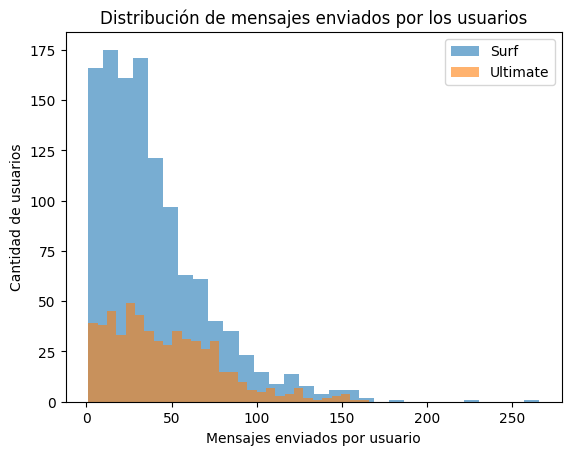

In [41]:
#Distribución de la columna 'sms_id'
# Llamamos dos veces a plt.hist() para crear dos histogramas en el mismo gráfico
plt.hist(consumption_and_plans[consumption_and_plans['plan_name']=='surf']['sms_id'], bins=30, alpha=0.6, label='Surf')
plt.hist(consumption_and_plans[consumption_and_plans['plan_name']=='ultimate']['sms_id'], bins=30, alpha=0.6, label='Ultimate')
plt.title('Distribución de mensajes enviados por los usuarios')
plt.xlabel('Mensajes enviados por usuario')
plt.ylabel('Cantidad de usuarios')
plt.legend()
plt.show()

In [42]:
# Calcula la media y la varianza de los mensajes enviados por los usuarios.
#Filtramos por plan y calculamos la media y la varianza respectivamente
surf_mean_messages = consumption_and_plans[consumption_and_plans['plan_name']=='surf']['sms_id'].mean()
surf_var_messages = np.var(consumption_and_plans[consumption_and_plans['plan_name']=='surf']['sms_id'], ddof=1)
print('Media de los mensajes enviados al mes por los usuarios del plan Surf:', surf_mean_messages)
print('Varianza de los mensajes enviados al mes por los usuarios del plan Surf:', surf_var_messages)
print()
ultimate_mean_messages = consumption_and_plans[consumption_and_plans['plan_name']=='ultimate']['sms_id'].mean()
ultimate_var_messages = np.var(consumption_and_plans[consumption_and_plans['plan_name']=='ultimate']['sms_id'], ddof=1)
print('Media de los mensajes enviados al mes por los usuarios del plan Ultimate:', ultimate_mean_messages)
print('Varianza de los mensajes enviados al mes por los usuarios del plan Ultimate:', ultimate_var_messages)

Media de los mensajes enviados al mes por los usuarios del plan Surf: 39.489830508474576
Varianza de los mensajes enviados al mes por los usuarios del plan Surf: 1044.2178778338437

Media de los mensajes enviados al mes por los usuarios del plan Ultimate: 46.534602076124564
Varianza de los mensajes enviados al mes por los usuarios del plan Ultimate: 1082.6859756646056


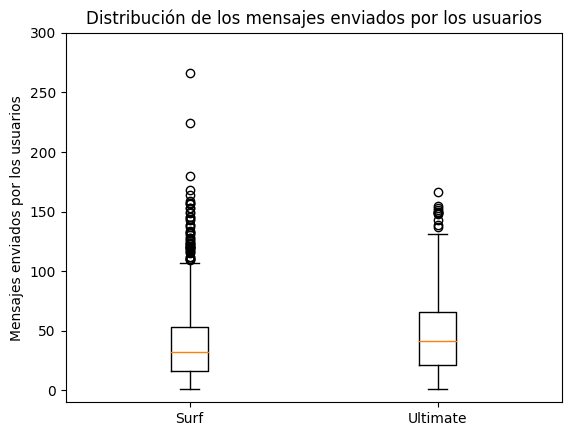

In [43]:
# Traza un diagrama de caja para visualizar la distribución de los mensajes enviados por los usuarios

plt.boxplot([consumption_and_plans[consumption_and_plans['plan_name']=='surf']['sms_id'],
           consumption_and_plans[consumption_and_plans['plan_name']=='ultimate']['sms_id']],
            labels=['Surf', 'Ultimate'])
plt.title('Distribución de los mensajes enviados por los usuarios')
plt.ylabel('Mensajes enviados por los usuarios')
plt.ylim([-10, 300])
plt.show()

**¿El comportamiento de los usuarios con respecto a los mensajes varía según el plan? Sí. En primer lugar, en ambos planes, la cantidad de mensajes enviados aumenta gradualmente por mes, pero, la cantidad de mensajes enviados por mes en el plan surf tiende a ser mayor que en el plan ultimate. En segundo lugar, con el transcurso de los meses se genera una diferencia cada vez mayor entre la cantidad de mensajes enviados de los dos planes. Ahora, sobre la distribución de los mensajes; en ambos planes, la mayoría de los usuarios no envían más de 75 mensajes. También podemos observar que los usuarios que llegan a enviar más de 200 mensajes tienden a ser del plan surf. Y para completar, el promedio de mensajes enviados por los usuarios del plan Surf es de 39.48, mientras que el del plan Ultimate es de 46.53**

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Perfecto Angel has identificado de manera efectiva que, aunque ambos planes muestran un aumento gradual en la cantidad de mensajes enviados, el plan Surf tiende a superar al plan Ultimate en este aspecto, y la diferencia entre ambos se acentúa con el tiempo.

</div>

### Internet

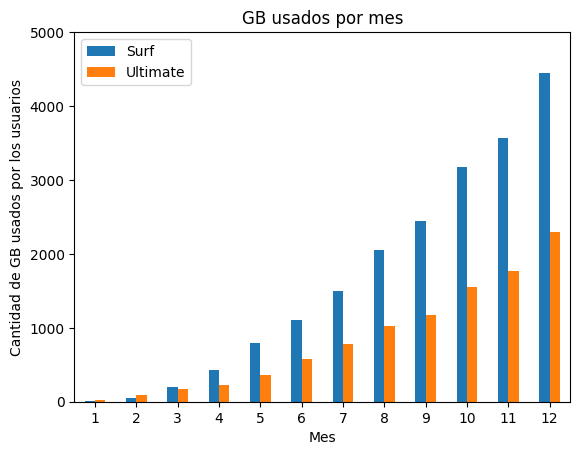

In [44]:
#La columna 'gb_used' por cada mes, de cada plan

monthly_gb_surf = consumption_and_plans[consumption_and_plans['plan_name']=='surf'].groupby('month')['gb_used'].sum()
monthly_gb_ultimate = consumption_and_plans[consumption_and_plans['plan_name']=='ultimate'].groupby('month')['gb_used'].sum()

monthly_gb_both_plans = pd.DataFrame({'Surf':monthly_gb_surf, 'Ultimate':monthly_gb_ultimate})

monthly_gb_both_plans.plot(kind='bar', rot=0)
plt.xlabel('Mes')
plt.ylabel('Cantidad de GB usados por los usuarios')
plt.title('GB usados por mes')
plt.ylim([0, 5000])
plt.show()

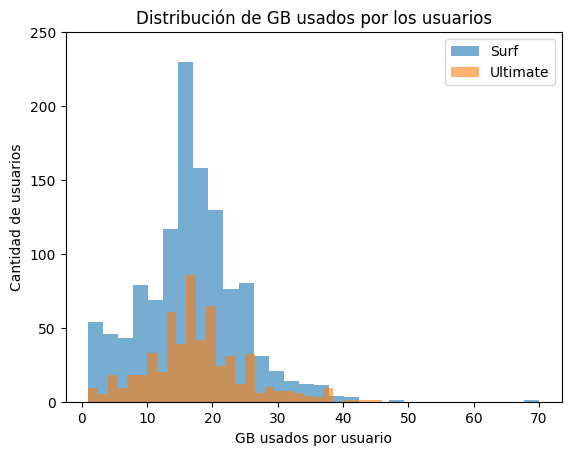

In [45]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
#Compara la columna 'gb_used' por plan
# Llamamos dos veces a plt.hist() para crear dos histogramas en el mismo gráfico
plt.hist(consumption_and_plans[consumption_and_plans['plan_name']=='surf']['gb_used'], bins=30, alpha=0.6, label='Surf')
plt.hist(consumption_and_plans[consumption_and_plans['plan_name']=='ultimate']['gb_used'], bins=30, alpha=0.6, label='Ultimate')
plt.title('Distribución de GB usados por los usuarios')
plt.xlabel('GB usados por usuario')
plt.ylabel('Cantidad de usuarios')
plt.legend()
plt.ylim([0, 250])
plt.show()

In [46]:
# Calcula la media y la varianza de los GB usados por los usuarios.
#Filtramos por plan y calculamos la media y la varianza respectivamente
surf_mean_gb = consumption_and_plans[consumption_and_plans['plan_name']=='surf']['gb_used'].mean()
surf_var_gb = np.var(consumption_and_plans[consumption_and_plans['plan_name']=='surf']['gb_used'], ddof=1)
print('Media de los GB usados al mes por los usuarios del plan Surf:', surf_mean_gb)
print('Varianza de los GB usados al mes por los usuarios del plan Surf:', surf_var_gb)
print()
ultimate_mean_gb = consumption_and_plans[consumption_and_plans['plan_name']=='ultimate']['gb_used'].mean()
ultimate_var_gb = np.var(consumption_and_plans[consumption_and_plans['plan_name']=='ultimate']['gb_used'], ddof=1)
print('Media de los GB usados al mes por los usuarios del plan Ultimate:', ultimate_mean_gb)
print('Varianza de los GB usados al mes por los usuarios del plan Ultimate:', ultimate_var_gb)

Media de los GB usados al mes por los usuarios del plan Surf: 16.752542372881354
Varianza de los GB usados al mes por los usuarios del plan Surf: 57.01250413306307

Media de los GB usados al mes por los usuarios del plan Ultimate: 17.3719723183391
Varianza de los GB usados al mes por los usuarios del plan Ultimate: 55.807670626615405


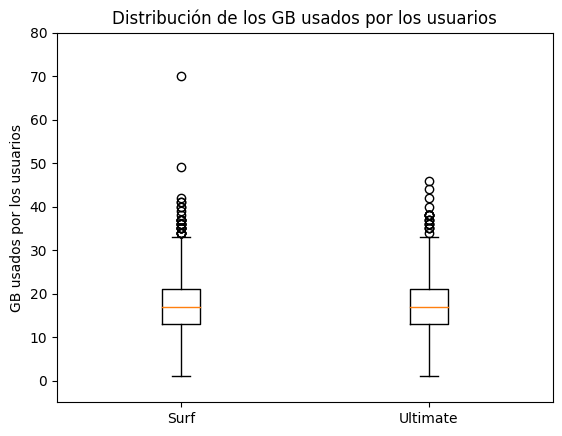

In [47]:
# Traza un diagrama de caja para visualizar la distribución de los GB usados por los usuarios

plt.boxplot([consumption_and_plans[consumption_and_plans['plan_name']=='surf']['gb_used'],
           consumption_and_plans[consumption_and_plans['plan_name']=='ultimate']['gb_used']],
           labels=['Surf', 'Ultimate'])
plt.title('Distribución de los GB usados por los usuarios')
plt.ylabel('GB usados por los usuarios')
plt.ylim([-5, 80])
plt.show()

**¿El comportamiento de los usuarios con respecto al consumo de GB varía según el plan?
Sí. En primer lugar, en ambos planes, la cantidad de GB usados aumenta gradualmente por mes, pero, la cantidad de GB usados por mes en el plan surf tiende a ser mayor que en el plan ultimate. En segundo lugar, con el transcurso de los meses se genera una diferencia cada vez mayor entre la cantidad de GB usados de los dos planes. Ahora, sobre la distribución de GB; en ambos planes, la mayoría de los usuarios gasta menos de 30 GB. También, podemos observar que los usuarios que llegan a gastar más de 65 GB tienden a ser del plan surf. Y para completar, el promedio de GB usados por los usuarios del plan Surf es de 16.75, mientras que el del plan Ultimate es de 17.37.**

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>
    
Angel resaltas acertadamente que la mayoría de los usuarios en ambos planes no superan los 30 GB, pero aquellos que consumen más de 65 GB suelen ser del plan Surf, lo que sugiere un uso más intensivo de datos en este plan. Para futuros análisis, podrías explorar las razones detrás de estas diferencias, como las necesidades específicas de los usuarios o las características de los planes, lo que enriquecería aún más tu interpretación. 


</div>

## Ingreso

           Surf  Ultimate
month                    
1         20.00     210.0
2        119.57     350.0
3        616.65     546.0
4       1420.70    1169.0
5       2695.43    1491.0
6       3645.67    2667.0
7       5500.77    3402.0
8       7661.59    4130.0
9       8407.94    5068.0
10     11831.67    6349.0
11     12451.42    7287.0
12     16919.28    9093.0


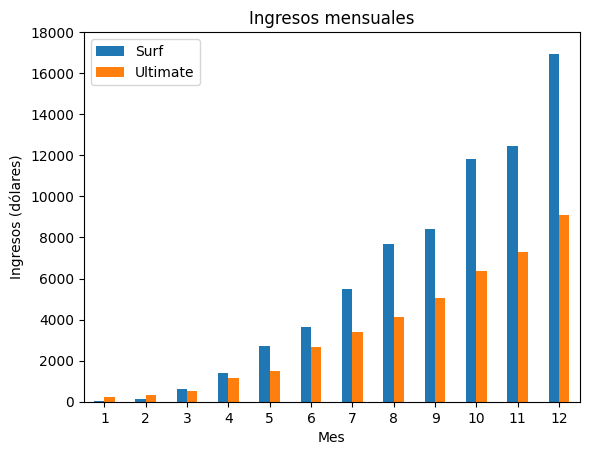

In [48]:
#Calcular el ingreso mensual de cada plan. Compararlos en un gráfico de barras
#Filtramos por plan, agrupamos por mes y sacamos la suma de la columna 'monthly_income'
surf_monthly_income = consumption_and_plans[consumption_and_plans['plan_name']=='surf'].groupby('month')['monthly_income'].sum()
ultimate_monthly_income = consumption_and_plans[consumption_and_plans['plan_name']=='ultimate'].groupby('month')['monthly_income'].sum()
both_plans_monthly_income = pd.DataFrame({'Surf':surf_monthly_income, 'Ultimate':ultimate_monthly_income})
print(both_plans_monthly_income)
both_plans_monthly_income.plot(kind='bar', rot=0)
plt.title('Ingresos mensuales')
plt.xlabel('Mes')
plt.ylabel('Ingresos (dólares)')
plt.legend()
plt.ylim([0, 18000])
plt.show()

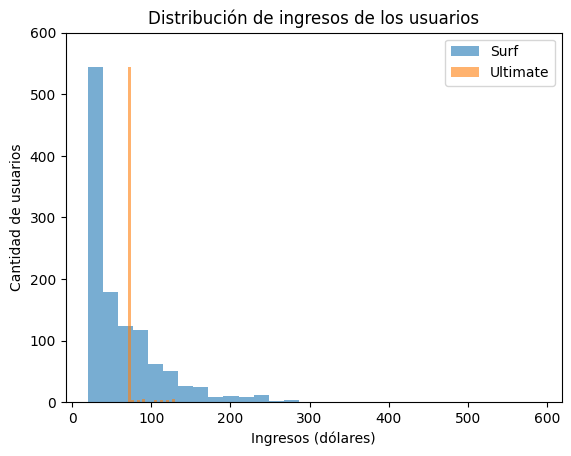

In [49]:
#Distribución de los ingresos mensuales
# Llamamos dos veces a plt.hist() para crear dos histogramas en el mismo gráfico
plt.hist(consumption_and_plans[consumption_and_plans['plan_name']=='surf']['monthly_income'], bins=30, alpha=0.6, label='Surf')
plt.hist(consumption_and_plans[consumption_and_plans['plan_name']=='ultimate']['monthly_income'], bins=30, alpha=0.6, label='Ultimate')
plt.title('Distribución de ingresos de los usuarios')
plt.xlabel('Ingresos (dólares)')
plt.ylabel('Cantidad de usuarios')
plt.legend()
plt.ylim([0, 600])
plt.show()

In [50]:
#Calcular media y varianza de los ingresos mensuales generados
#Filtramos por plan y calculamos la media y la varianza respectivamente
surf_mean_income = consumption_and_plans[consumption_and_plans['plan_name']=='surf']['monthly_income'].mean()
surf_var_income = np.var(consumption_and_plans[consumption_and_plans['plan_name']=='surf']['monthly_income'], ddof=1)
print('Media de los ingresos mensuales generados por los usuarios del plan Surf:', surf_mean_income)
print('Varianza de los ingresos mensuales generados por los usuarios del plan Surf:', surf_var_income)
print()
ultimate_mean_income = consumption_and_plans[consumption_and_plans['plan_name']=='ultimate']['monthly_income'].mean()
ultimate_var_income = np.var(consumption_and_plans[consumption_and_plans['plan_name']=='ultimate']['monthly_income'], ddof=1)
print('Media de los ingresos mensuales generados por los usuarios del plan Ultimate:', ultimate_mean_income)
print('Varianza de los ingresos mensuales generados por los usuarios del plan Ultimate:', ultimate_var_income)

Media de los ingresos mensuales generados por los usuarios del plan Surf: 60.41583898305085
Varianza de los ingresos mensuales generados por los usuarios del plan Surf: 2872.5032153260454

Media de los ingresos mensuales generados por los usuarios del plan Ultimate: 72.25259515570934
Varianza de los ingresos mensuales generados por los usuarios del plan Ultimate: 121.9603485394566


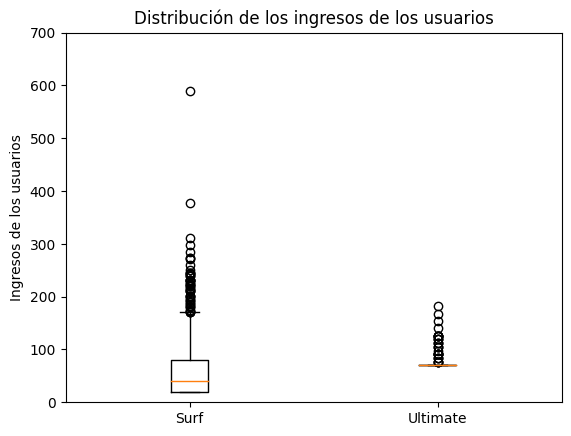

In [51]:
#Vizualizar la distribución de los ingresos con un diagrama de caja
plt.boxplot([consumption_and_plans[consumption_and_plans['plan_name']=='surf']['monthly_income'],
        consumption_and_plans[consumption_and_plans['plan_name']=='ultimate']['monthly_income']],
        labels=['Surf', 'Ultimate'])
plt.title('Distribución de los ingresos de los usuarios')
plt.ylabel('Ingresos de los usuarios')
plt.ylim([0, 700])
plt.show()

**¿Cómo difiere el ingreso entre los planes? A pesar de que en ambos planes los ingresos aumentan gradualmente por mes, el plan Surf tiende a generar más ingresos por mes que el plan Ultimate. Únicamente en los primeros dos meses del año, el plan Ultimate generó más ingresos que el plan Surf, pero de ahí en adelante este último predominó. Además, con el transcurso de los meses se genera una diferencia cada vez mayor entre los ingresos generados de los dos planes. Ahora, con respecto a la distribución de los ingresos; en ambos planes, la mayoría de los usuarios no genera más de 100 dólares al mes. Los usuarios que llegan a generar más de 200 dólares mensuales pertenecen al plan Surf. Aunado a lo anterior, solo dos usuarios del plan Surf generaron aproximadamente 400 y 600 dólares respectivamente. Asimismo, el ingreso mensual promedio del plan Surf es de 60.41, mientras que el del plan Ultimate es de 72.25**

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Angel tu análisis sobre la diferencia de ingresos entre los planes es claro y bien estructurado. Has identificado de manera efectiva que, aunque ambos planes muestran un aumento gradual en los ingresos, el plan Surf tiende a superar al plan Ultimate a partir del tercer mes, y la diferencia entre ambos se acentúa con el tiempo. Como una idea hacia futuros podrías explorar las razones detrás de estas diferencias, como el perfil de los usuarios o las estrategias de precios de cada plan, lo que enriquecería aún más tu interpretación. ¡Buen trabajo en la presentación y análisis de los datos!

</div>

## Prueba las hipótesis estadísticas

In [52]:
# Prueba las hipótesis:
# Hipótesis nula: Los ingresos promedio de los planes Surf y Ultimate son iguales
# Hipótesis alternativa: Los ingresos promedio de los planes Surf y Ultimate son diferentes (mayor o menor)
# Haremos una prueba de hipótesis bilateral ya que simplemente queremos saber si son diferentes (sin importar el sentido).
surf_income = consumption_and_plans[consumption_and_plans['plan_name']=='surf']['monthly_income'] #filtramos por plan
ultimate_income = consumption_and_plans[consumption_and_plans['plan_name']=='ultimate']['monthly_income']#filtramos por plan
alpha = 0.05 #establecemos la significación estadística

#Determinar si las varianzas son iguales
#(este paso lo busqué en internet ya que aún no me quedaba claro cómo determinar si las varianzas son iguales o no)
levene_test = st.levene(surf_income, ultimate_income)
equal_var = levene_test.pvalue > alpha

#Realizamos la prueba de hipótesis
results = st.ttest_ind(surf_income, ultimate_income, equal_var=equal_var) # utilizamos ttest_ind ya que se trata de dos muestras independientes
print('Valor p:', results.pvalue)

if (results.pvalue < alpha):
    print('Rechazamos la hipótesis nula. Los ingresos promedio de los planes Surf y Ultimate son diferentes')
else:
    print('No podemos rechazar la hipótesis nula. No hay evidencia suficiente para determinar si los ingresos promedio de los planes Surf y Ultimate son diferentes')

Valor p: 5.697848749357263e-13
Rechazamos la hipótesis nula. Los ingresos promedio de los planes Surf y Ultimate son diferentes


In [53]:
# Prueba las hipótesis
# Hipótesis nula: El ingreso promedio de los usuarios del área NY-NJ es igual al de los usuarios de otras regiones.
# Hipótesis alternativa: El ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.
# Realizaremos una prueba de hipótesis bilateral ya que solo queremos saber si las medias son diferentes (sin importar el sentido).

#Filtramos el dataframe por ciudad y seleccionamos la columna de ingresos mensuales
ny_nj_users_income = consumption_and_plans[consumption_and_plans['city'].str.contains('ny-nj', na=False)]['monthly_income'] #llamamos a na=False en caso de que hayan valores ausentes (aunque no debería)
other_users_income = consumption_and_plans[~consumption_and_plans['city'].str.contains('ny-nj', na=False)]['monthly_income']
#Asignamos la significación estadística
alpha=0.05
#Determinar si las varianzas son iguales
#(este paso lo busqué en internet ya que aún no me quedaba claro cómo determinar si las varianzas son iguales o no)
# Prueba de Levene para comprobar si las varianzas son iguales
levene_test = st.levene(ny_nj_users_income, other_users_income)
equal_var = levene_test.pvalue > alpha

#Utilizamos ttest_ind debido a que los usuarios del área NY-NJ son totalmente independientes a los de otras áreas
results = st.ttest_ind(ny_nj_users_income, other_users_income, equal_var=equal_var)
print('Valor p:', results.pvalue)

if (results.pvalue < alpha):
    print('Rechazamos la hipótesis nula. El ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.')
else:
    print('No podemos rechazar la hipótesis nula. No hay evidencia suficiente para determinar si el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.')

Valor p: 0.010053583550147672
Rechazamos la hipótesis nula. El ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

¡Buen trabajo Angel! Aplicaste correctamente la prueba de hipótesis comparando la media de muestras independientes e incluiste la prueba de Levene, lo cual es clave para verificar la similitud de las varianzas y garantizar que la prueba t sea estadísticamente válida.

</div>

## Conclusión general

#1. Para el análisis correcto de este proyecto, se realizó una limpieza de datos que abarcó pasos como: cambiar el tipo de datos, estandarizar columnas, corregir errores, revisar datos duplicados y revisar valores ausentes.

#2. También, se enriquecieron algunas tablas agregandoles columnas que fueran de utilidad y que facilitaban el análisis.

#3. Al mismo tiempo, se fusionaron varios dataframes para al final obtener toda la información escencial en una sola tabla de datos.

#4. Por cada plan, se crearon gráficos de barras para visualizar el comportamiento de los usuarios con respecto a su consumo mensual de llamadas, mensajes y volumen de datos, así como histogramas y diagramas de caja para visualizar la distribución de estos mismos y su frecuencia de usuarios; se calcularon las medias y las varianzas de la duración de llamadas, mensajes y datos a nivel mensual.

#5. Nuevamente, se creó un gráfico de barras para observar y comparar los ingresos mensuales de los dos planes, así como un histograma y un diagrama de caja para comparar la frecuencia de usuarios que generan cierto rango de ingresos de los dos planes; asimismo, se calculó la media y la varianza de los ingresos mensuales de cada uno para un mejor panorama.

#6. Finalmente, se realizaron pruebas de hipótesis estadísticas, en las que se elaboró una hipótesis nula y alternativa para cada prueba. Se eligió el tipo de prueba a usar dependiendo del contexto y se determinó el grado de significación para realizar la prueba.

## Resultados de gráficas

Antes de continuar, cabe destacar que la cantidad de usuarios que utilizan el plan surf es mayor a la del plan ultimate, lo que podría influir significativamente sobre la diferencia de comportamientos.

##### DIFERENCIA DE MINUTOS
En primer lugar, podemos observar que la duración promedio de llamadas del plan surf va aumentando cada mes de una forma un poco más gradual que la del plan ultimate. En segundo lugar, existe una diferencia notoria de duración promedio de llamadas entre planes en los primeros tres meses. Por otro lado, a medida que los meses pasan, la duración promedio de las llamadas de los dos planes se van igualando entre sí. Aunado a esto, podemos observar que el plan ultimate constó de un aumento distinguido en la duración promedio de sus llamadas de enero a febrero. Ahora, sobre la distribución de los minutos; en ambos planes, la mayoría de los usuarios utilizan menos de 600 minutos. También podemos observar que aunque son menos los usuarios que utilizan el plan ultimate, la cantidad de usuarios que usaron más de 1200 minutos es mayor en este plan.

##### DIFERENCIA DE MENSAJES
En primer lugar, en ambos planes, la cantidad de mensajes enviados aumenta gradualmente por mes, pero, la cantidad de mensajes enviados por mes en el plan surf tiende a ser mayor que en el plan ultimate. En segundo lugar, con el transcurso de los meses se genera una diferencia cada vez mayor entre la cantidad de mensajes enviados de los dos planes. Ahora, sobre la distribución de los mensajes; en ambos planes, la mayoría de los usuarios no envían más de 75 mensajes. También podemos observar que los usuarios que llegan a enviar más de 200 mensajes tienden a ser del plan surf.

##### DIFERENCIA DE GB
En primer lugar, en ambos planes, la cantidad de GB usados aumenta gradualmente por mes, pero, la cantidad de GB usados por mes en el plan surf tiende a ser mayor que en el plan ultimate. En segundo lugar, con el transcurso de los meses se genera una diferencia cada vez mayor entre la cantidad de GB usados de los dos planes. Ahora, sobre la distribución de GB; en ambos planes, la mayoría de los usuarios gasta menos de 30 GB. También, podemos observar que los usuarios que llegan a gastar más de 65 GB tienden a ser del plan surf.

##### DIFERENCIA DE INGRESOS
A pesar de que en ambos planes los ingresos aumentan gradualmente por mes, el plan Surf tiende a generar más ingresos por mes que el plan Ultimate. Únicamente en los primeros dos meses del año, el plan Ultimate generó más ingresos que el plan Surf, pero de ahí en adelante este último predominó. Además, con el transcurso de los meses se genera una diferencia cada vez mayor entre los ingresos generados de los dos planes. Ahora, con respecto a la distribución de los ingresos; en ambos planes, la mayoría de los usuarios no genera más de 100 dólares al mes. Los usuarios que llegan a generar más de 200 dólares mensuales pertenecen al plan Surf. Aunado a lo anterior, solo dos usuarios del plan Surf generaron aproximadamente 400 y 600 dólares respectivamente.

## Resultados de hipótesis
##### PRIMERA HIPÓTESIS:
Se probó la hipótesis alternativa de que el promedio de los ingresos de los planes Surf y Ultimate son diferentes. Para esto, se consideraron dos muestras independientes (una por cada plan) y el uso de una prueba bilateral.

El resultado de la prueba mostró que los ingresos promedio de ambos planes son significativamente diferentes (se rechazó la hipótesis nula).

###### SEGUNDA HIPÓTESIS:
Se probó la hipótesis alternativa de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones. Para esto, se consideraron dos muestras independientes (zona NY-NJ, otras zonas) y el uso de una prueba bilateral.

El resultado de la prueba mostró que el ingreso promedio de los usuarios del área NY-NJ es significativamente diferente al de los usuarios de otras regiones (se rechazó la hipótesis nula).

## Conclusión final

Se recomienda a la empresa Megaline ajustar su presupuesto de publicidad con base a los resultados obtenidos por las pruebas de hipótesis; apoyándose también, en la información proporcionada por las gráficas generadas.


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Tu análisis demuestra un enfoque metódico y detallado, destacando tu capacidad para limpiar, enriquecer y fusionar datos de manera efectiva, lo que facilitó la obtención de resultados claros y útiles. Has logrado identificar diferencias clave en el comportamiento de los usuarios entre los planes Surf y Ultimate, resaltando aspectos como el consumo de minutos, mensajes, GB y los ingresos generados. Además, la aplicación de pruebas de hipótesis estadísticas añadió rigor a tu análisis, permitiendo conclusiones sólidas sobre las diferencias entre los planes y las regiones. Si quisieramos ir un paso más alla, podrías profundizar en el análisis de los factores que influyen en las diferencias observadas, como el perfil demográfico de los usuarios o las estrategias de marketing, lo que enriquecería aún más tus conclusiones. ¡Excelente trabajo en la organización, análisis y presentación de los datos!

</div>